In [1]:
!pip install tensorflow opencv-python matplotlib scikit-learn

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 2.9/351.2 MB 16.7 MB/s eta 0:00:21
    --------------------------------------- 6.0/351.2 MB 15.5 MB/s eta 0:00:23
   - -------------------------------------- 8.9/351.2 MB 15.2 MB/s eta 0:00:23
   - -------------------------------------- 12.1/351.2 MB 15.0 MB/s eta 0:00:23
   - -------------------------------------- 15.2/351.2 MB 14.9 MB/s eta 0:00:23
   -- ------------------------------------- 18.1/351.2 MB 14.8 MB/s eta 0:00:23
   -- ------------------------------------- 21.2/351.2 MB 14.8 MB/s eta 0:00:23
   -- ------------------------------------- 24.1/351.2 MB 14.8 MB/s eta 0:00:23
   --- ------------------------------------ 27.3/351.2 MB 14.7 MB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [2]:


import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [1]:

DATASET_PATH = "Data"

IMG_SIZE = 64

In [9]:


data = []
labels = []

print("Loading images...")

for folder in os.listdir(DATASET_PATH):

    folder_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(folder_path):

        for image_name in os.listdir(folder_path):

            image_path = os.path.join(folder_path, image_name)

            try:
                # Read image
                img = cv2.imread(image_path)

                # Convert BGR to RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Resize image
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # Normalize
                img = img / 255.0

                data.append(img)
                labels.append(folder)

            except Exception as e:
                print(f"Error loading image: {image_path}")

print("Images Loaded Successfully!")

Loading images...
Images Loaded Successfully!


In [10]:


X = np.array(data)
y = np.array(labels)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (4972, 64, 64, 3)
Shape of y: (4972,)


In [11]:


encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

y_categorical = to_categorical(y_encoded)

print("Classes:", encoder.classes_)

Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S'
 'T' 'U' 'V' 'W' 'X' 'Y']


In [12]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_categorical
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 3977
Testing Samples: 995


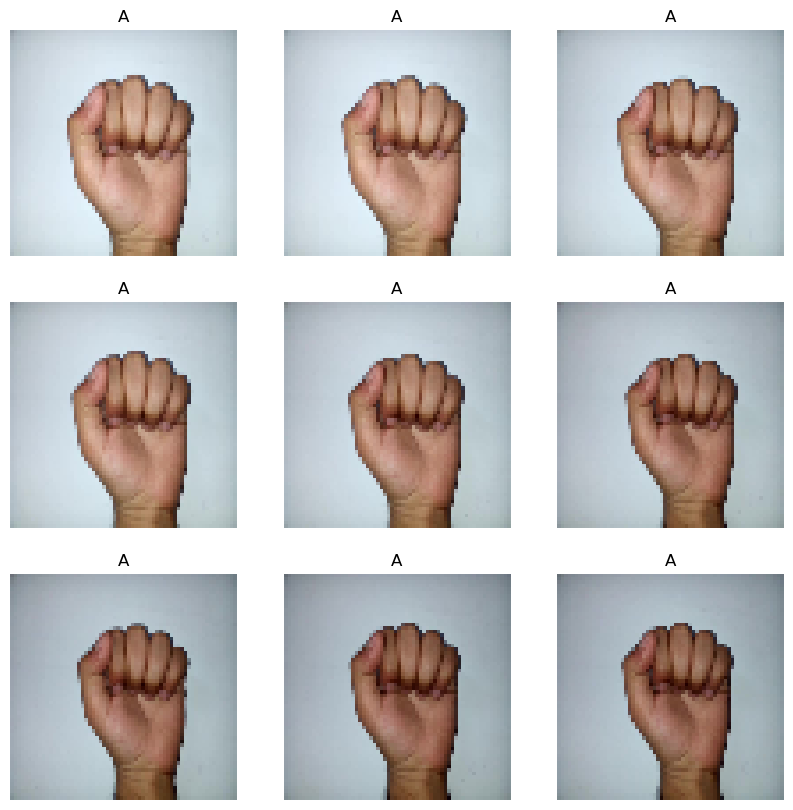

In [13]:

plt.figure(figsize=(10, 10))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(X[i])

    plt.title(labels[i])

    plt.axis("off")

plt.show()

In [14]:

model = Sequential()

# First CNN Layer
model.add(Conv2D(
    32,
    (3, 3),
    activation='relu',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
))

model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Second CNN Layer
model.add(Conv2D(64, (3, 3), activation='relu'))

model.add(BatchNormalization())

model.add(MaxPooling2D((2, 2)))

# Third CNN Layer
model.add(Conv2D(128, (3, 3), activation='relu'))

model.add(BatchNormalization())

model.add(MaxPooling2D((2, 2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

# Output Layer
model.add(Dense(len(encoder.classes_), activation='softmax'))

C:\Users\lenix\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687,192 (2.62 MB)

 Trainable params: 686,744 (2.62 MB)

 Non-trainable params: 448 (1.75 KB)

In [16]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [17]:

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.5532 - loss: 1.5724 - val_accuracy: 0.0241 - val_loss: 15.8025
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.8396 - loss: 0.5045 - val_accuracy: 0.0241 - val_loss: 12.8555
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.9072 - loss: 0.2717 - val_accuracy: 0.1347 - val_loss: 6.5500
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.9326 - loss: 0.2073 - val_accuracy: 0.6633 - val_loss: 1.1339
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9537 - loss: 0.1353 - val_accuracy: 0.9487 - val_loss: 0.1309
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.9633 - loss: 0.1064 - val_accuracy: 0.9869 - val_loss: 0.0322
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9698 - loss: 0.0927 - val_accuracy: 0.7317 - val_loss: 1.6336
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.9708 - loss: 0.0798 - v

In [18]:

loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9869 - loss: 0.0322
Test Accuracy: 98.69%


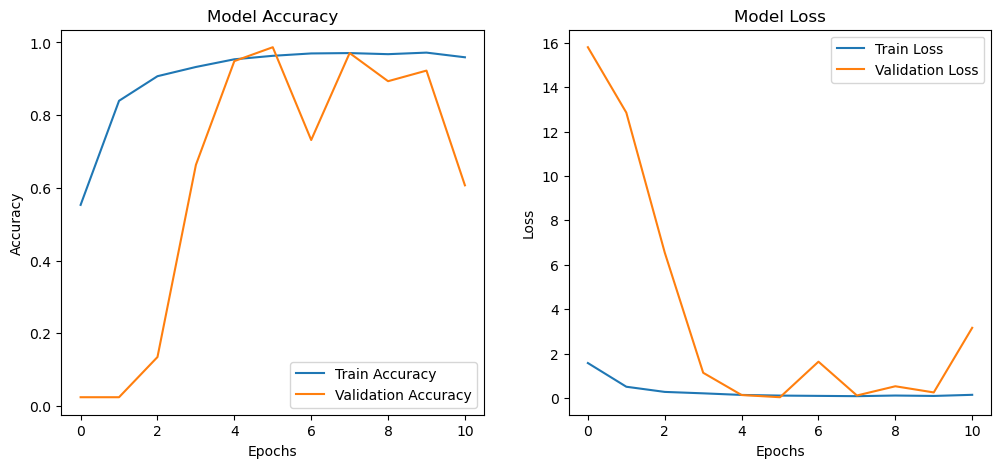

In [19]:

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Train Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)

plt.plot(history.history['loss'], label='Train Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()

In [20]:

model.save("indian_sign_language_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


In [21]:

def predict_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img_normalized = img_resized / 255.0

    img_input = np.expand_dims(img_normalized, axis=0)

    prediction = model.predict(img_input)

    predicted_class = np.argmax(prediction)

    sign = encoder.inverse_transform([predicted_class])

    plt.imshow(img)

    plt.title(f"Predicted Sign: {sign[0]}")

    plt.axis("off")

    plt.show()

    print("Predicted Sign:", sign[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


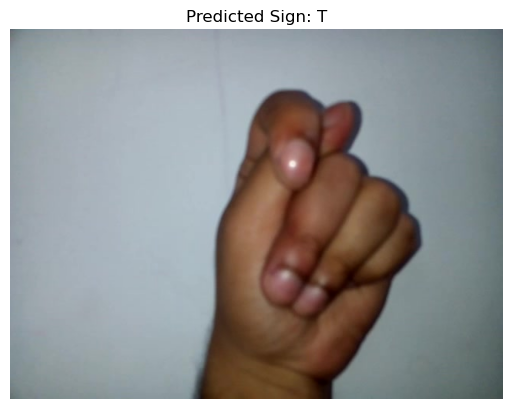

Predicted Sign: T


In [23]:

predict_image("Data/T/014.jpg")